In [2]:
import pandas as pd
from pathlib import Path

# Path to our one-stock, one-day LOBSTER sample
file_path = Path("../data/sample/ko/2025-06-30/KO_2025-06-30_24900000_57900000_message_0.csv")

print("File found:", file_path.exists())


File found: True


In [3]:
# LOBSTER message-file column names
columns = [
    "time",
    "event_type",
    "order_id",
    "size",
    "price",
    "direction",
    "extra"
]

df = pd.read_csv(
    file_path,
    header=None,
    names=columns
)

print("Number of events:", len(df))
df.head(10)

Number of events: 327986


,time,event_type,order_id,size,price,direction,extra
0,11115.073436,7,0,0,1,-1,NaN
1,14400.009448,1,1643,100,698400,1,NaN
2,14400.009524,1,1655,100,704000,-1,NaN
3,14400.166962,3,1655,100,704000,-1,NaN
4,14400.166962,1,19907,100,703600,-1,NaN
5,14400.167662,3,1643,100,698400,1,NaN
6,14400.167662,1,20423,100,699600,1,NaN
7,14400.442594,1,37519,5,703500,-1,NaN
8,14401.021847,1,53487,1000,670000,1,NaN
9,14401.094350,3,19907,100,703600,-1,NaN


In [4]:
# Inspect the structure of the KO message data

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nEvent type counts:")
print(df["event_type"].value_counts().sort_index())

print("\nTime range:")
print("First timestamp:", df["time"].min())
print("Last timestamp:", df["time"].max())

print("\nMissing values:")
print(df.isna().sum())

Shape: (327986, 7)

Column names:
['time', 'event_type', 'order_id', 'size', 'price', 'direction', 'extra']

Event type counts:
event_type
1    160312
2       709
3    150375
4     12411
5      4176
6         2
7         1
Name: count, dtype: int64

Time range:
First timestamp: 11115.073435767
Last timestamp: 72000.241537144

Missing values:
time               0
event_type         0
order_id           0
size               0
price              0
direction          0
extra         283836
dtype: int64


In [5]:
# Convert LOBSTER seconds-after-midnight into readable timestamps

date = pd.Timestamp("2025-06-30")

df["datetime"] = date + pd.to_timedelta(df["time"], unit="s")

# Create market-session labels
def classify_session(timestamp):
    t = timestamp.time()

    if t < pd.Timestamp("09:30:00").time():
        return "Pre-open"
    elif t <= pd.Timestamp("16:00:00").time():
        return "Regular"
    else:
        return "Post-market"

df["session"] = df["datetime"].apply(classify_session)

print("First observation:", df["datetime"].min())
print("Last observation:", df["datetime"].max())

print("\nEvents by market session:")
print(df["session"].value_counts())

df[["datetime", "event_type", "size", "price", "direction", "session"]].head(10)

First observation: 2025-06-30 03:05:15.073435767
Last observation: 2025-06-30 20:00:00.241537144

Events by market session:
session
Regular        323753
Pre-open         2851
Post-market      1382
Name: count, dtype: int64


,datetime,event_type,size,price,direction,session
0,2025-06-30 03:05:15.073435767,7,0,1,-1,Pre-open
1,2025-06-30 04:00:00.009448348,1,100,698400,1,Pre-open
2,2025-06-30 04:00:00.009524452,1,100,704000,-1,Pre-open
3,2025-06-30 04:00:00.166961908,3,100,704000,-1,Pre-open
4,2025-06-30 04:00:00.166961908,1,100,703600,-1,Pre-open
5,2025-06-30 04:00:00.167661565,3,100,698400,1,Pre-open
6,2025-06-30 04:00:00.167661565,1,100,699600,1,Pre-open
7,2025-06-30 04:00:00.442593684,1,5,703500,-1,Pre-open
8,2025-06-30 04:00:01.021847332,1,1000,670000,1,Pre-open
9,2025-06-30 04:00:01.094349779,3,100,703600,-1,Pre-open


In [6]:
# Isolate trade execution events
# LOBSTER:
# 4 = execution of visible limit order
# 5 = execution of hidden limit order

executions = df[df["event_type"].isin([4, 5])].copy()

# LOBSTER prices are stored as price × 10,000
executions["price_dollars"] = executions["price"] / 10000

print("Total executions:", len(executions))

print("\nExecutions by type:")
print(executions["event_type"].value_counts().sort_index())

print("\nExecutions by market session:")
print(executions["session"].value_counts())

print("\nExecution time range:")
print("First execution:", executions["datetime"].min())
print("Last execution:", executions["datetime"].max())

executions[
    ["datetime", "event_type", "order_id",
     "size", "price_dollars", "direction", "session"]
].head(10)

Total executions: 16587

Executions by type:
event_type
4    12411
5     4176
Name: count, dtype: int64

Executions by market session:
session
Regular        16204
Pre-open         276
Post-market      107
Name: count, dtype: int64

Execution time range:
First execution: 2025-06-30 04:00:01.414313065
Last execution: 2025-06-30 19:55:30.578405894


,datetime,event_type,order_id,size,price_dollars,direction,session
13,2025-06-30 04:00:01.414313065,4,56395,10,70.28,-1,Pre-open
87,2025-06-30 04:01:05.361819083,5,0,1,70.27,1,Pre-open
221,2025-06-30 04:06:51.558096856,5,0,1,70.28,1,Pre-open
250,2025-06-30 04:13:53.709383147,4,1896591,4,70.28,1,Pre-open
265,2025-06-30 04:14:07.190208379,5,0,12,70.27,1,Pre-open
266,2025-06-30 04:14:07.190208940,5,0,12,70.27,1,Pre-open
267,2025-06-30 04:14:07.190216546,5,0,6,70.27,1,Pre-open
268,2025-06-30 04:14:07.190216546,5,0,2,70.27,1,Pre-open
269,2025-06-30 04:14:07.190366926,4,1467791,1,70.26,1,Pre-open
270,2025-06-30 04:14:07.190366926,4,1549015,11,70.26,1,Pre-open


In [7]:
# Determine aggressor side for execution events
# LOBSTER direction refers to the resting order:
# +1 = resting buy order  -> seller initiated
# -1 = resting sell order -> buyer initiated

executions["aggressor_sign"] = -executions["direction"]

executions["aggressor_side"] = executions["aggressor_sign"].map({
    1: "Buy",
    -1: "Sell"
})

print("Executions by aggressor side:")
print(executions["aggressor_side"].value_counts())

print("\nExecutions by aggressor side and session:")
print(pd.crosstab(
    executions["session"],
    executions["aggressor_side"]
))

executions[
    [
        "datetime",
        "event_type",
        "size",
        "price_dollars",
        "direction",
        "aggressor_sign",
        "aggressor_side",
        "session"
    ]
].head(15)

Executions by aggressor side:
aggressor_side
Sell    9930
Buy     6657
Name: count, dtype: int64

Executions by aggressor side and session:
aggressor_side   Buy  Sell
session                   
Post-market       11    96
Pre-open          93   183
Regular         6553  9651


,datetime,event_type,size,price_dollars,direction,aggressor_sign,aggressor_side,session
13,2025-06-30 04:00:01.414313065,4,10,70.28,-1,1,Buy,Pre-open
87,2025-06-30 04:01:05.361819083,5,1,70.27,1,-1,Sell,Pre-open
221,2025-06-30 04:06:51.558096856,5,1,70.28,1,-1,Sell,Pre-open
250,2025-06-30 04:13:53.709383147,4,4,70.28,1,-1,Sell,Pre-open
265,2025-06-30 04:14:07.190208379,5,12,70.27,1,-1,Sell,Pre-open
266,2025-06-30 04:14:07.190208940,5,12,70.27,1,-1,Sell,Pre-open
267,2025-06-30 04:14:07.190216546,5,6,70.27,1,-1,Sell,Pre-open
268,2025-06-30 04:14:07.190216546,5,2,70.27,1,-1,Sell,Pre-open
269,2025-06-30 04:14:07.190366926,4,1,70.26,1,-1,Sell,Pre-open
270,2025-06-30 04:14:07.190366926,4,11,70.26,1,-1,Sell,Pre-open


In [8]:
# Calculate executed dollar value

executions["notional"] = (
    executions["size"] * executions["price_dollars"]
)

print("Total executed shares:", executions["size"].sum())
print("Total executed notional: $",
      round(executions["notional"].sum(), 2))

print("\nBy session:")
print(
    executions.groupby("session")
    .agg(
        executions=("event_type", "count"),
        shares=("size", "sum"),
        notional=("notional", "sum")
    )
)

Total executed shares: 1275324
Total executed notional: $ 89873620.57

By session:
             executions   shares      notional
session                                       
Post-market         107     1618  1.143398e+05
Pre-open            276     5106  3.587455e+05
Regular           16204  1268600  8.940054e+07


In [9]:
# Create clean regular-session execution sample

regular_exec = executions[
    executions["session"] == "Regular"
].copy()

# Keep economically meaningful executions
regular_exec = regular_exec[
    (regular_exec["size"] > 0) &
    (regular_exec["price_dollars"] > 0)
].copy()

print("Regular-session executions:", len(regular_exec))
print("Regular-session shares:", regular_exec["size"].sum())
print(
    "Regular-session notional: $",
    round(regular_exec["notional"].sum(), 2)
)

print("\nAggressor-side counts:")
print(regular_exec["aggressor_side"].value_counts())

regular_exec[
    [
        "datetime",
        "event_type",
        "size",
        "price_dollars",
        "aggressor_side",
        "notional"
    ]
].head(10)

Regular-session executions: 16204
Regular-session shares: 1268600
Regular-session notional: $ 89400535.28

Aggressor-side counts:
aggressor_side
Sell    9651
Buy     6553
Name: count, dtype: int64


,datetime,event_type,size,price_dollars,aggressor_side,notional
2885,2025-06-30 09:30:01.157917117,4,3,70.23,Buy,210.69
2889,2025-06-30 09:30:01.158366809,4,52,70.24,Buy,3652.48
2890,2025-06-30 09:30:01.158420006,4,100,70.24,Buy,7024.00
2900,2025-06-30 09:30:01.175433196,5,100,70.23,Sell,7023.00
2901,2025-06-30 09:30:01.175459036,5,110,70.23,Sell,7725.30
2902,2025-06-30 09:30:01.175484748,4,100,70.22,Sell,7022.00
2903,2025-06-30 09:30:01.175484748,4,10,70.21,Sell,702.10
2905,2025-06-30 09:30:01.175511074,4,90,70.21,Sell,6318.90
2908,2025-06-30 09:30:01.175656662,4,100,70.20,Sell,7020.00
2923,2025-06-30 09:30:01.176349341,4,100,70.22,Buy,7022.00


In [10]:
# Aggregate executions into 1-minute intervals

regular_exec["minute"] = regular_exec["datetime"].dt.floor("min")

# Signed volume:
# + size = buyer-initiated execution
# - size = seller-initiated execution
regular_exec["signed_volume"] = (
    regular_exec["size"] * regular_exec["aggressor_side"]
)

minute_data = (
    regular_exec
    .groupby("minute")
    .agg(
        trades=("event_type", "count"),
        volume=("size", "sum"),
        signed_volume=("signed_volume", "sum"),
        notional=("notional", "sum"),
        avg_trade_price=("price_dollars", "mean")
    )
    .reset_index()
)

print("Number of 1-minute intervals:", len(minute_data))

minute_data.head(10)

Number of 1-minute intervals: 389


,minute,trades,volume,signed_volume,notional,avg_trade_price
0,2025-06-30 09:30:00,244,20992,BuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyB...,1473395.360,70.196250
1,2025-06-30 09:31:00,120,8914,BuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyB...,626884.900,70.324125
2,2025-06-30 09:32:00,135,12158,SellSellSellSellSellSellSellSellSellSellSellSe...,857002.130,70.485630
3,2025-06-30 09:33:00,92,7144,BuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyB...,503986.845,70.538207
4,2025-06-30 09:34:00,113,8553,BuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyB...,604002.425,70.619027
5,2025-06-30 09:35:00,56,4289,SellSellSellSellSellSellSellSellSellSellSellSe...,302814.955,70.600804
6,2025-06-30 09:36:00,55,3323,SellSellSellSellSellSellSellSellSellSellSellSe...,234711.990,70.636091
7,2025-06-30 09:37:00,50,2877,BuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyB...,203381.000,70.690700
8,2025-06-30 09:38:00,59,4230,SellSellSellSellSellSellSellSellSellSellSellSe...,299022.885,70.691017
9,2025-06-30 09:39:00,38,2264,BuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuyBuySellSellSe...,160117.785,70.718816


In [11]:
# Convert aggressor side to numeric sign
side_sign = {
    "Buy": 1,
    "Sell": -1
}

regular_exec["side_sign"] = regular_exec["aggressor_side"].map(side_sign)

# Correct signed volume
regular_exec["signed_volume"] = (
    regular_exec["size"] * regular_exec["side_sign"]
)

# Rebuild 1-minute dataset
regular_exec["minute"] = regular_exec["datetime"].dt.floor("min")

minute_data = (
    regular_exec
    .groupby("minute")
    .agg(
        trades=("event_type", "count"),
        volume=("size", "sum"),
        signed_volume=("signed_volume", "sum"),
        notional=("notional", "sum"),
        avg_trade_price=("price_dollars", "mean")
    )
    .reset_index()
)

print("Number of 1-minute intervals:", len(minute_data))
minute_data.head(10)

Number of 1-minute intervals: 389


,minute,trades,volume,signed_volume,notional,avg_trade_price
0,2025-06-30 09:30:00,244,20992,-4654,1473395.360,70.196250
1,2025-06-30 09:31:00,120,8914,-1254,626884.900,70.324125
2,2025-06-30 09:32:00,135,12158,1346,857002.130,70.485630
3,2025-06-30 09:33:00,92,7144,2482,503986.845,70.538207
4,2025-06-30 09:34:00,113,8553,-3223,604002.425,70.619027
5,2025-06-30 09:35:00,56,4289,-2737,302814.955,70.600804
6,2025-06-30 09:36:00,55,3323,-919,234711.990,70.636091
7,2025-06-30 09:37:00,50,2877,-1603,203381.000,70.690700
8,2025-06-30 09:38:00,59,4230,-794,299022.885,70.691017
9,2025-06-30 09:39:00,38,2264,-1338,160117.785,70.718816


In [12]:
# Calculate normalized order flow imbalance

minute_data["ofi"] = (
    minute_data["signed_volume"] / minute_data["volume"]
)

print("OFI summary:")
print(minute_data["ofi"].describe())

print("\nFirst 10 intervals:")
minute_data[
    ["minute", "volume", "signed_volume", "ofi"]
].head(10)

OFI summary:
count    389.000000
mean      -0.242578
std        0.483742
min       -1.000000
25%       -0.590989
50%       -0.242236
75%        0.115952
max        1.000000
Name: ofi, dtype: float64

First 10 intervals:


,minute,volume,signed_volume,ofi
0,2025-06-30 09:30:00,20992,-4654,-0.221704
1,2025-06-30 09:31:00,8914,-1254,-0.140678
2,2025-06-30 09:32:00,12158,1346,0.110709
3,2025-06-30 09:33:00,7144,2482,0.347424
4,2025-06-30 09:34:00,8553,-3223,-0.376827
5,2025-06-30 09:35:00,4289,-2737,-0.638144
6,2025-06-30 09:36:00,3323,-919,-0.276557
7,2025-06-30 09:37:00,2877,-1603,-0.557178
8,2025-06-30 09:38:00,4230,-794,-0.187707
9,2025-06-30 09:39:00,2264,-1338,-0.590989


In [13]:
# Calculate volume-weighted execution price (VWAP) for each minute

regular_exec["dollar_volume"] = (
    regular_exec["size"] * regular_exec["price_dollars"]
)

minute_vwap = (
    regular_exec
    .groupby("minute")
    .apply(
        lambda x: x["dollar_volume"].sum() / x["size"].sum(),
        include_groups=False
    )
)

minute_data["vwap"] = minute_data["minute"].map(minute_vwap)

# Log price change from one minute to the next
import numpy as np

minute_data["price_change"] = (
    np.log(minute_data["vwap"]).diff()
)

print(
    minute_data[
        ["minute", "volume", "signed_volume", "ofi",
         "vwap", "price_change"]
    ].head(10)
)

print("\nPrice-change summary:")
print(minute_data["price_change"].describe())

               minute  volume  signed_volume       ofi       vwap  \
0 2025-06-30 09:30:00   20992          -4654 -0.221704  70.188422   
1 2025-06-30 09:31:00    8914          -1254 -0.140678  70.325881   
2 2025-06-30 09:32:00   12158           1346  0.110709  70.488742   
3 2025-06-30 09:33:00    7144           2482  0.347424  70.546871   
4 2025-06-30 09:34:00    8553          -3223 -0.376827  70.618780   
5 2025-06-30 09:35:00    4289          -2737 -0.638144  70.602694   
6 2025-06-30 09:36:00    3323           -919 -0.276557  70.632558   
7 2025-06-30 09:37:00    2877          -1603 -0.557178  70.692040   
8 2025-06-30 09:38:00    4230           -794 -0.187707  70.690989   
9 2025-06-30 09:39:00    2264          -1338 -0.590989  70.723403   

   price_change  
0           NaN  
1      0.001957  
2      0.002313  
3      0.000824  
4      0.001019  
5     -0.000228  
6      0.000423  
7      0.000842  
8     -0.000015  
9      0.000458  

Price-change summary:
count    388.000000

In [14]:
# First market-impact regression
# Relationship between signed volume and execution-price change

import numpy as np

impact_df = minute_data[
    ["minute", "signed_volume", "volume", "ofi", "price_change"]
].dropna().copy()

# Scale signed volume to thousands of shares for easier interpretation
impact_df["signed_volume_1000"] = impact_df["signed_volume"] / 1000

# Simple OLS using NumPy
x = impact_df["signed_volume_1000"].values
y = impact_df["price_change"].values

slope, intercept = np.polyfit(x, y, 1)

# Predicted values
y_hat = intercept + slope * x

# R-squared
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - ss_res / ss_tot

# Correlation
correlation = np.corrcoef(x, y)[0, 1]

print("MARKET IMPACT RESULTS")
print("---------------------")
print("Observations:", len(impact_df))
print("Intercept:", intercept)
print("Impact coefficient:", slope)
print("R-squared:", r_squared)
print("Correlation:", correlation)

print("\nImpact coefficient in basis points")
print("per 1,000 net shares:", slope * 10000)

MARKET IMPACT RESULTS
---------------------
Observations: 388
Intercept: 3.094310800065293e-05
Impact coefficient: 1.51751152502824e-05
R-squared: 0.009770241722407258
Correlation: 0.09884453309317277

Impact coefficient in basis points
per 1,000 net shares: 0.151751152502824


In [15]:
# Market-impact regression using normalized trade-flow imbalance

impact_df2 = minute_data[
    ["minute", "ofi", "price_change"]
].dropna().copy()

x = impact_df2["ofi"].values
y = impact_df2["price_change"].values

slope_ofi, intercept_ofi = np.polyfit(x, y, 1)

y_hat = intercept_ofi + slope_ofi * x

ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared_ofi = 1 - ss_res / ss_tot
correlation_ofi = np.corrcoef(x, y)[0, 1]

print("NORMALIZED TRADE-FLOW IMPACT")
print("----------------------------")
print("Observations:", len(impact_df2))
print("Intercept:", intercept_ofi)
print("OFI coefficient:", slope_ofi)
print("R-squared:", r_squared_ofi)
print("Correlation:", correlation_ofi)

print("\nApprox. price response in basis points")
print("for a +1 change in imbalance:", slope_ofi * 10000)

NORMALIZED TRADE-FLOW IMPACT
----------------------------
Observations: 388
Intercept: 4.6269747970079144e-05
OFI coefficient: 0.00010737627883932382
R-squared: 0.027079903927208937
Correlation: 0.16455972753747836

Approx. price response in basis points
for a +1 change in imbalance: 1.0737627883932381


In [16]:
# Test whether current trade-flow imbalance predicts NEXT-minute price change

# Shift the price change backward so each row contains the
# price movement that occurs after that minute's order flow
minute_data["next_price_change"] = minute_data["price_change"].shift(-1)

lead_df = minute_data[
    ["minute", "ofi", "next_price_change"]
].dropna().copy()

x = lead_df["ofi"].values
y = lead_df["next_price_change"].values

slope_lead, intercept_lead = np.polyfit(x, y, 1)

y_hat = intercept_lead + slope_lead * x

ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared_lead = 1 - ss_res / ss_tot
correlation_lead = np.corrcoef(x, y)[0, 1]

print("NEXT-MINUTE MARKET IMPACT")
print("-------------------------")
print("Observations:", len(lead_df))
print("Intercept:", intercept_lead)
print("OFI coefficient:", slope_lead)
print("R-squared:", r_squared_lead)
print("Correlation:", correlation_lead)

print("\nApprox. next-minute price response in basis points")
print("for a +1 change in imbalance:", slope_lead * 10000)

NEXT-MINUTE MARKET IMPACT
-------------------------
Observations: 388
Intercept: 6.0276371870571476e-05
OFI coefficient: 0.00016525220722009024
R-squared: 0.06413687038268112
Correlation: 0.2532525821836395

Approx. next-minute price response in basis points
for a +1 change in imbalance: 1.6525220722009024


In [17]:
# Statistical significance of next-minute relationship

from scipy.stats import linregress

reg = linregress(
    lead_df["ofi"],
    lead_df["next_price_change"]
)

print("NEXT-MINUTE REGRESSION SIGNIFICANCE")
print("-----------------------------------")
print("Slope:", reg.slope)
print("Intercept:", reg.intercept)
print("R-squared:", reg.rvalue ** 2)
print("Correlation:", reg.rvalue)
print("P-value:", reg.pvalue)
print("Standard error:", reg.stderr)

print("\nImpact coefficient in basis points:")
print(reg.slope * 10000)

NEXT-MINUTE REGRESSION SIGNIFICANCE
-----------------------------------
Slope: 0.00016525220722009027
Intercept: 6.027637187057138e-05
R-squared: 0.06413687038268108
Correlation: 0.2532525821836395
P-value: 4.3029066163230976e-07
Standard error: 3.212964323811347e-05

Impact coefficient in basis points:
1.6525220722009026


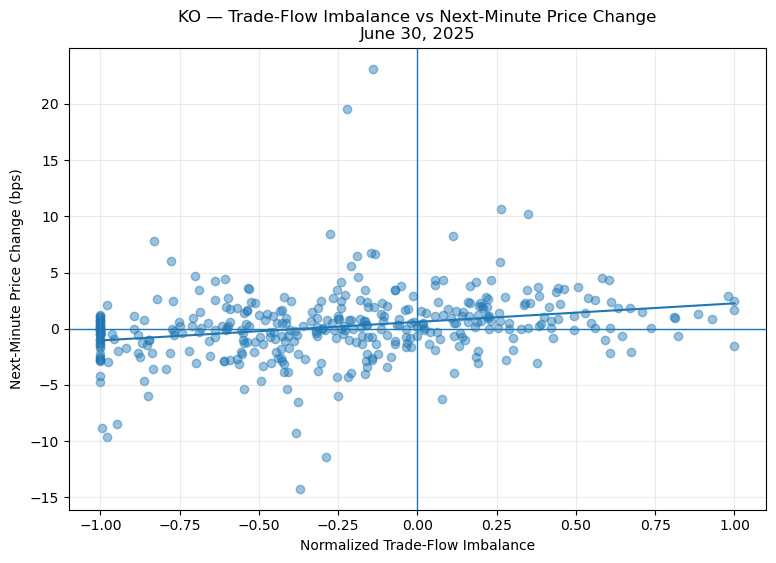

In [18]:
import matplotlib.pyplot as plt

# Convert next-minute return to basis points
lead_df["next_return_bps"] = lead_df["next_price_change"] * 10000

plt.figure(figsize=(9, 6))

plt.scatter(
    lead_df["ofi"],
    lead_df["next_return_bps"],
    alpha=0.45
)

# Regression line
x_line = np.linspace(
    lead_df["ofi"].min(),
    lead_df["ofi"].max(),
    100
)

y_line = (
    intercept_lead + slope_lead * x_line
) * 10000

plt.plot(x_line, y_line)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Normalized Trade-Flow Imbalance")
plt.ylabel("Next-Minute Price Change (bps)")
plt.title(
    "KO — Trade-Flow Imbalance vs Next-Minute Price Change\n"
    "June 30, 2025"
)

plt.grid(alpha=0.25)
plt.show()

In [19]:
# Robustness check: remove extreme 1% tails of next-minute returns

lower = lead_df["next_price_change"].quantile(0.01)
upper = lead_df["next_price_change"].quantile(0.99)

robust_df = lead_df[
    lead_df["next_price_change"].between(lower, upper)
].copy()

robust_reg = linregress(
    robust_df["ofi"],
    robust_df["next_price_change"]
)

print("ROBUSTNESS CHECK — 1% RETURN TAILS REMOVED")
print("------------------------------------------")
print("Original observations:", len(lead_df))
print("Remaining observations:", len(robust_df))
print("Removed observations:", len(lead_df) - len(robust_df))

print("\nOFI coefficient:", robust_reg.slope)
print("Impact coefficient (bps):", robust_reg.slope * 10000)
print("Correlation:", robust_reg.rvalue)
print("R-squared:", robust_reg.rvalue ** 2)
print("P-value:", robust_reg.pvalue)

ROBUSTNESS CHECK — 1% RETURN TAILS REMOVED
------------------------------------------
Original observations: 388
Remaining observations: 380
Removed observations: 8

OFI coefficient: 0.00013964159620323546
Impact coefficient (bps): 1.3964159620323546
Correlation: 0.28019947060153894
R-squared: 0.07851174332538269
P-value: 2.7637558182337574e-08
